# Host Classification
- Class-Conditional Validity Envelopes - Rather than constructing a single 35-dimensional envelope  
- No Imputation
- No Empty Sets

In [42]:
import os
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

### Loading the Data

In [43]:
DATA_DIR = "../Data"
SCORES_PATH = f"{DATA_DIR}/phage_host_scores.parquet"
METADATA_PATH = f"{DATA_DIR}/metadata.csv"
alpha = 0.1

print("Loading phage-level host scores...")
t0 = time.time()
phage_scores = pd.read_parquet(SCORES_PATH)
print(f"  shape : {phage_scores.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata...")
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
# One row per phage: take first protein's metadata per accession
phage_meta = (meta_df.reset_index().groupby("accession")[["host", "host_type", "split"]].first())
print(f"  phage_meta shape : {phage_meta.shape}")

Loading phage-level host scores...
  shape : (18443, 2036)  (0.5s)
Loading metadata...
  phage_meta shape : (18474, 3)


#### Joining scores with labels

In [44]:
phage_df = phage_scores.join(phage_meta, how="inner")
phage_df["split"] = phage_df["split"].astype(int)

print(f"\nPhage-level shape after join: {phage_df.shape}")
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())
print("\nHost distribution (top 15):")
print(phage_df["host"].value_counts().head(15))


Phage-level shape after join: (18443, 2039)

Split distribution:
split
0    4422
1    3169
2    3638
3    3584
4    3630
Name: count, dtype: int64

Host distribution (top 15):
host
Mycobacterium     2352
Escherichia       2254
Pseudomonas       1023
Klebsiella         966
Salmonella         958
Vibrio             917
Streptococcus      740
Gordonia           657
Staphylococcus     652
Microbacterium     545
Bacillus           440
Ralstonia          412
Arthrobacter       397
Synechococcus      392
Lactococcus        388
Name: count, dtype: int64


#### Identifying the score columns and host 

In [45]:
score_cols = [c for c in phage_scores.columns]

# Host genus = prefix before first underscore
all_hosts = sorted(set(c.split("_")[0] for c in score_cols))
print(f"Host: {len(all_hosts)}")
print(all_hosts)

# Map each host to its column indices
host_col_map = {h: [i for i, c in enumerate(score_cols) if c.split("_")[0] == h] for h in all_hosts}
print("\nColumns per host (sample):")
for h in all_hosts:
    print(f"  {h}: {len(host_col_map[h])} columns")

Host: 54
['Campylobacter', 'Caulobacter', 'Cellulophaga', 'Citrobacter', 'Clostridioides', 'Clostridium', 'Corynebacterium', 'Cronobacter', 'Dickeya', 'Edwardsiella', 'Enterobacter', 'Enterococcus', 'Erwinia', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Haloarcula', 'Halorubrum', 'Klebsiella', 'Lacticaseibacillus', 'Lactobacillus', 'Lactococcus', 'Listeria', 'Microbacterium', 'Microcystis', 'Mycobacterium', 'Paenibacillus', 'Pantoea', 'Pectobacterium', 'Pelagibacter', 'Prochlorococcus', 'Propionibacterium', 'Proteus', 'Providencia', 'Pseudoalteromonas', 'Pseudomonas', 'Ralstonia', 'Rhizobium', 'Rhodobacter', 'Roseobacter', 'Salmonella', 'Serratia', 'Shewanella', 'Shigella', 'Sinorhizobium', 'Staphylococcus', 'Stenotrophomonas', 'Streptococcus', 'Streptomyces', 'Sulfolobus', 'Synechococcus', 'Vibrio', 'Xanthomonas', 'Yersinia']

Columns per host (sample):
  Campylobacter: 40 columns
  Caulobacter: 40 columns
  Cellulophaga: 36 columns
  Citrobacter: 40 columns
  Clostridioides: 36 col

### Gram-Type Setup
Moved here (before train/test split, before any envelope is built) instead of bolted on at the end. Two things are computed:

1. `host_to_gramtype` / `gram_pos_hosts` / `gram_neg_hosts` — ground truth, from metadata.
2. `candidate_hosts_for(accession)` — the actually-usable restriction at test time, based on the **predicted** gram-type from `Gram_Classification.ipynb`'s output, not the ground truth (you don't know ground truth at prediction time).

Added a check that was missing before: whether every host actually has a gram-type label, and whether the label strings (`"gram-pos"` / `"gram-neg"`) actually match what's in the metadata. If this prints hosts with no gram-type or the counts look off, stop — the restriction below will silently fall back to `all_hosts` for those and the whole exercise does nothing for them.

In [46]:
# Ground-truth host -> gram-type lookup (from metadata, not a prediction)
host_to_gramtype = (
    phage_df.dropna(subset=["host_type"])
    .drop_duplicates("host")
    .set_index("host")["host_type"]
    .to_dict()
)
print("Observed host_type values in metadata:", phage_df["host_type"].dropna().unique().tolist())

gram_pos_hosts = sorted(h for h in all_hosts if host_to_gramtype.get(h) == "gram-pos")
gram_neg_hosts = sorted(h for h in all_hosts if host_to_gramtype.get(h) == "gram-neg")
missing_gram = [h for h in all_hosts if h not in host_to_gramtype]

print(f"Gram-pos hosts: {len(gram_pos_hosts)}  |  Gram-neg hosts: {len(gram_neg_hosts)}")
missing_count = len(missing_gram)
if missing_count > 0:
    print(f"Warning: {missing_count} hosts have missing Gram labels.")

Observed host_type values in metadata: ['gram-neg', 'gram-pos']
Gram-pos hosts: 16  |  Gram-neg hosts: 38


In [47]:
# STEP 2 — load the PREDICTED gram-type sets from Gram_Classification.ipynb
gram_pred_df = pd.read_csv(f"gram_type_predictions.csv").set_index("accession")

def candidate_hosts_for(accession):
    if accession not in gram_pred_df.index:
        return all_hosts
    row = gram_pred_df.loc[accession]
    allowed = []
    if row["pred_gramneg"]: allowed += gram_neg_hosts
    if row["pred_grampos"]: allowed += gram_pos_hosts
    return allowed if allowed else all_hosts

### Train Test Split

In [48]:
phage_df = phage_df[phage_df["host"].isin(all_hosts)].copy()

train_df = phage_df[phage_df["split"] != 0].copy()
test_df = phage_df[phage_df["split"] == 0].copy()

print(f"Training phages (folds 1-4) : {len(train_df)}")
print(f"Test phages     (fold 0)    : {len(test_df)}")
print(f"\nTest host distribution:")
print(test_df["host"].value_counts())

Training phages (folds 1-4) : 11694
Test phages     (fold 0)    : 3944

Test host distribution:
host
Escherichia           856
Mycobacterium         497
Vibrio                279
Staphylococcus        235
Pseudomonas           196
Ralstonia             183
Salmonella            182
Klebsiella            168
Synechococcus         168
Streptococcus         160
Microbacterium        123
Propionibacterium     106
Gordonia               81
Enterococcus           72
Sulfolobus             55
Lactococcus            51
Shigella               46
Erwinia                38
Pelagibacter           31
Clostridium            29
Halorubrum             28
Flavobacterium         28
Yersinia               27
Streptomyces           22
Lactobacillus          21
Caulobacter            20
Rhizobium              19
Listeria               17
Cronobacter            16
Roseobacter            15
Enterobacter           15
Serratia               15
Pseudoalteromonas      14
Haloarcula             13
Corynebacterium

### Score characteristics
 -  For each host, the columns specific to that host should have higher mean scores for phages that actually infect that host.

In [49]:
print("Mean score at true-host columns vs all columns (training set):")
sample_hosts = all_hosts[:5]
for h in sample_hosts:
    h_idx = host_col_map[h]
    mask_h = train_df["host"] == h
    if mask_h.sum() == 0:
        continue
    true_host_mean = np.nanmean(train_df.loc[mask_h, score_cols].values[:, h_idx])
    all_mean = np.nanmean(train_df.loc[mask_h, score_cols].values)
    print(f"  {h}: true-host cols mean={true_host_mean:.3f}, "
          f"all cols mean={all_mean:.3f}, n={mask_h.sum()}")

Mean score at true-host columns vs all columns (training set):
  Campylobacter: true-host cols mean=0.207, all cols mean=0.052, n=96
  Caulobacter: true-host cols mean=0.271, all cols mean=0.058, n=31
  Cellulophaga: true-host cols mean=0.262, all cols mean=0.051, n=45
  Citrobacter: true-host cols mean=0.072, all cols mean=0.053, n=39
  Clostridioides: true-host cols mean=0.368, all cols mean=0.091, n=17


### Score Transformation
 -  For host classification: NC = 1 - raw_score
 - High raw score = strong infection evidence = low nonconformity

In [50]:
def raw_to_nc(raw_array):
    return np.where(np.isnan(raw_array), np.nan, 1.0 - raw_array)

train_raw = train_df[score_cols].values   # (n_train, K)
test_raw = test_df[score_cols].values    # (n_test,  K)
train_labels = train_df["host"].to_numpy(dtype=str)
test_labels = test_df["host"].to_numpy(dtype=str)

train_nc = raw_to_nc(train_raw)
test_nc = raw_to_nc(test_raw)

print(f"Train NC shape: {train_nc.shape}")
print(f"Test NC shape : {test_nc.shape}")
print(f"NaN fraction in train NC: {np.isnan(train_nc).mean():.3f}")
print(f"NaN fraction in test NC : {np.isnan(test_nc).mean():.3f}")

Train NC shape: (11694, 2036)
Test NC shape : (3944, 2036)
NaN fraction in train NC: 0.623
NaN fraction in test NC : 0.631


### Functions

In [51]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    vals = np.sort(tau_scores[labels == cls])
    n = len(vals)
    if n == 0:
        return 0.0
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]


def compute_t_hat_multiclass(tau_scores, labels, classes, alpha):
    """t_hat = max over all classes of the per-class (1-alpha) quantile."""
    return max(quantile_for_class(tau_scores, labels, c, alpha) for c in classes)

### 1D Collapsed Envelope

In [52]:
def collapsed_build_envelope(S1, S2, labels_S2, classes, alpha):
    S1_1d = np.nanmean(S1, axis=1, keepdims=True)
    S2_1d = np.nanmean(S2, axis=1, keepdims=True)
    q_tilde = np.nanquantile(S1_1d, 1 - alpha)
    tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}


def collapsed_tau(scores, envelope):
    scores_1d = np.nanmean(scores, axis=1)
    return scores_1d / (envelope["q_tilde"] * envelope["t_hat"] + 1e-12)


def collapsed_is_in_region(scores, envelope):
    return np.nanmean(scores, axis=1) <= envelope["q_tilde"] * envelope["t_hat"]

### Radial Envelope

In [53]:
def sample_positive_sphere(M, K):
    V = np.abs(np.random.randn(M, K))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)


def radial_build_envelope(S1, S2, labels_S2, classes, alpha, M=200, delta_deg=30):
    N1, K = S1.shape
    U = sample_positive_sphere(M, K)
    cos_thresh = np.cos(np.radians(delta_deg))

    mags = np.array([np.linalg.norm(S1[n, ~np.isnan(S1[n])]) for n in range(N1)])
    dirs = np.zeros((N1, K))
    for n in range(N1):
        valid = ~np.isnan(S1[n])
        if mags[n] > 1e-12:
            dirs[n, valid] = S1[n, valid] / mags[n]

    q_tilde = np.zeros(M)
    for m in range(M):
        cos_sims = dirs @ U[m]
        nearby = cos_sims >= cos_thresh
        src_mags = mags[nearby] if nearby.sum() > 5 else mags
        q_tilde[m] = np.quantile(src_mags, 1 - alpha)

    N2 = S2.shape[0]
    tau_scores = np.zeros(N2)
    boundary = U * q_tilde[:, None]
    for n in range(N2):
        valid = ~np.isnan(S2[n])
        if valid.sum() == 0:
            tau_scores[n] = 0.0
            continue
        ratios_m = (S2[n, valid][None, :] /
                    (boundary[:, valid] + 1e-12)).max(axis=1)
        tau_scores[n] = ratios_m.min()

    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}


def radial_tau(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    N = scores.shape[0]
    tau = np.zeros(N)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            tau[n] = 0.0
            continue
        ratios_m = (scores[n, valid][None, :] / (boundary[:, valid] + 1e-12)).max(axis=1)
        tau[n] = ratios_m.min()
    return tau


def radial_is_in_region(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    N = scores.shape[0]
    inside = np.zeros(N, dtype=bool)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            inside[n] = True
            continue
        inside[n] = np.any(np.all(scores[n, valid][None, :] <= boundary[:, valid], axis=1))
    return inside

### Strip Envelope

In [54]:
def strip_shape_discovery(S1, alpha, M):
    N1, K = S1.shape
    bin_edges = np.array([
        np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), M + 1)
        for j in range(K)
    ])
    limits = np.zeros((K, K, M))
    marginal_quantiles = np.array([
        np.nanquantile(S1[:, i], 1 - alpha) for i in range(K)
    ])
    for j in range(K):
        for m in range(M):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j:
                    continue
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                if src_mask.sum() >= 3:
                    limits[j, i, m] = np.quantile(S1[src_mask, i], 1 - alpha)
                else:
                    non_nan_i = S1[~np.isnan(S1[:, i]), i]
                    limits[j, i, m] = (
                        np.quantile(non_nan_i, 1 - alpha)
                        if len(non_nan_i) > 0 else marginal_quantiles[i]
                    )
    for j in range(K):
        for i in range(K):
            if i == j:
                continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits, marginal_quantiles


def get_bin_indices(scores, bin_edges):
    K = scores.shape[1]
    M = bin_edges.shape[1] - 1
    return np.array([np.clip(np.where(np.isnan(scores[:, j]), 0, np.digitize(scores[:, j], bin_edges[j]) - 1), 0, M - 1) for j in range(K)]).T


def strip_tau_scores(S, bin_edges, limits, marginal_quantiles):
    """Vectorised version — avoids the inner (j, i) Python loop."""
    N, K = S.shape
    bin_idx = get_bin_indices(S, bin_edges)   # (N, K)

    # Advanced indexing with broadcasting directly constructs the (N, K, K) array
    j_idx = np.arange(K)[None, :, None]
    i_idx = np.arange(K)[None, None, :]
    m_idx = bin_idx[:, :, None]
    
    lims = limits[j_idx, i_idx, m_idx]   # (N, K, K)

    S_i = S[:, np.newaxis, :]        # (N, 1, K) — broadcast over j
    S_j = S[:, :, np.newaxis]        # (N, K, 1) — broadcast over i

    nan_i = np.isnan(S_i)  # (N, 1, K)
    nan_j = np.isnan(S_j)  # (N, K, 1)

    mq = marginal_quantiles[np.newaxis, np.newaxis, :]  # (1, 1, K)

    ratio = np.zeros((N, K, K))

    both_avail = (~nan_i) & (~nan_j)   # (N, K, K)
    miss_i = nan_i & (~nan_j)

    # Standard: s_i / lim
    ratio = np.where(both_avail, np.broadcast_to(S_i, (N, K, K)) / (lims + 1e-12), ratio)
    # Missing dim i: marginal / lim
    ratio = np.where(miss_i, np.broadcast_to(mq, (N, K, K)) / (lims + 1e-12), ratio)

    # Zero out diagonal (i == j)
    diag_mask = np.eye(K, dtype=bool)[np.newaxis, :, : ]
    ratio = np.where(diag_mask, 0.0, ratio)

    return ratio.max(axis=(1, 2))


def strip_build_envelope(S1, S2, labels_S2, classes, alpha, M=2):
    bin_edges, limits, marginal_quantiles = strip_shape_discovery(S1, alpha, M)
    tau_scores = strip_tau_scores(S2, bin_edges, limits, marginal_quantiles)
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {
        "bin_edges": bin_edges,
        "limits": limits,
        "marginal_quantiles": marginal_quantiles,
        "t_hat": t_hat,
        "method": "strip"
    }


def strip_tau(scores, envelope):
    raw = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return raw / (envelope["t_hat"] + 1e-12)


def strip_is_in_region(scores, envelope):
    tau = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return tau <= envelope["t_hat"]

In [55]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_is_in_region(scores, envelope)
    return collapsed_is_in_region(scores, envelope)


def compute_tau(scores, envelope):
    if envelope["method"] == "collapsed":
        return collapsed_tau(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_tau(scores, envelope)
    return radial_tau(scores, envelope)

### Envelope construction
- Building an envelope per host. 
- For each host
    - Extract only the K_h columns specific to host h
    - Build a separate envelope calibrated on training phages with true host h
    - At test time, check each hypothesis h using its K_h-dim NC sub-vector

In [56]:
def build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                              method="collapsed", seed=42):
    rng = np.random.default_rng(seed)
    envelopes = {}

    for h in all_hosts:
        h_idx = host_col_map[h]
        if len(h_idx) == 0:
            continue

        mask_h = train_labels == h
        n_h = mask_h.sum()
        if n_h < 6:
            # Too few training phages to split S1/S2 meaningfully
            print(f"  SKIP {h}: only {n_h} training phages")
            continue

        train_nc_h = train_nc[mask_h][:, h_idx]   # (n_h, K_h)

        # 50/50 shuffle split into S1 and S2
        idx = rng.permutation(n_h)
        half = n_h // 2
        S1 = train_nc_h[idx[:half]]
        S2 = train_nc_h[idx[half:]]
        labels_S2 = np.array([h] * len(S2))

        if method == "collapsed":
            env = collapsed_build_envelope(S1, S2, labels_S2, [h], alpha)
        elif method == "radial":
            env = radial_build_envelope(S1, S2, labels_S2, [h], alpha)
        else:
            env = strip_build_envelope(S1, S2, labels_S2, [h], alpha)

        envelopes[h] = {"envelope": env, "col_indices": h_idx}

    print(f"  Built {len(envelopes)} host envelopes")
    return envelopes

### Host prediction

In [57]:
def predict_host(test_raw, per_host_envelopes, all_hosts):
    """
    Vectorised: for each host h, check ALL test phages at once.
    Builds an (N, n_hosts) boolean matrix, then assembles prediction sets.
    """
    N = len(test_raw)
    active_hosts = [h for h in all_hosts if h in per_host_envelopes]
    n_h = len(active_hosts)

    inside_matrix = np.zeros((N, n_h), dtype=bool)
    tau_matrix = np.zeros((N, n_h), dtype=float)

    for j, h in enumerate(active_hosts):
        h_idx = per_host_envelopes[h]["col_indices"]
        env_h = per_host_envelopes[h]["envelope"]

        raw_h = test_raw[:, h_idx]
        nc_h = np.where(np.isnan(raw_h), np.nan, 1.0 - raw_h)

        inside_matrix[:, j] = is_in_region(nc_h, env_h)
        tau_matrix[:, j] = compute_tau(nc_h, env_h)

    results = []
    for i in range(N):
        pred_set = [active_hosts[j] for j in range(n_h) if inside_matrix[i, j]]
        forced = False
        if len(pred_set) == 0:
            forced = True
            best_j = int(np.argmin(tau_matrix[i]))
            pred_set = [active_hosts[best_j]]
        results.append({
            "prediction_set": pred_set,
            "forced":         forced,
            "tau_per_host":   {active_hosts[j]: tau_matrix[i, j] for j in range(n_h)}
        })
    return results

#### Evaluation

In [58]:
def evaluate_multiclass(results, true_labels, all_hosts, alpha):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(
        true_labels[i] in r["prediction_set"] for i, r in enumerate(results)
    )
    forced = sum(r["forced"] for r in results)
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]

    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)

    per_host_coverage = {}
    for h in all_hosts:
        h_idx = [i for i, lbl in enumerate(true_labels) if lbl == h]
        if not h_idx:
            continue
        per_host_coverage[h] = sum(true_labels[i] in results[i]["prediction_set"] for i in h_idx) / len(h_idx)

    return {
        "coverage":           covered / n,
        "avg_set_size":       np.mean(set_sizes),
        "singleton_rate":     len(singletons) / n,
        "singleton_accuracy": (correct_singletons / len(singletons) if singletons else None),
        "forced_rate":        forced / n,
        "set_sizes":          set_sizes,
        "per_host_coverage":  per_host_coverage,
        "min_host_coverage":  min(per_host_coverage.values()) if per_host_coverage else None,
    }

### Evaluating on split 0 phages

In [59]:
print("\n" + "="*60)
print(" BASELINE — no gram-type filtering (kept only for comparison) ")
print("="*60)
print("\nBuilding collapsed envelopes...")
per_host_envs_c = build_per_host_envelopes(
    train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
    method="collapsed", seed=42)
collapsed_results_unrestricted = predict_host(test_raw, per_host_envs_c, all_hosts)
collapsed_metrics_unrestricted = evaluate_multiclass(
    collapsed_results_unrestricted, test_labels, all_hosts, alpha)
print(f"  coverage={collapsed_metrics_unrestricted['coverage']:.3f}  "
      f"avg_set_size={collapsed_metrics_unrestricted['avg_set_size']:.2f}")


 BASELINE — no gram-type filtering (kept only for comparison) 

Building collapsed envelopes...


  Built 54 host envelopes
  coverage=0.928  avg_set_size=7.15


In [60]:
h = all_hosts[4]
print(f"Host: {h}")
print(f"Number of columns for {h}: {len(host_col_map[h])}")
print(f"Number of training phages for {h}: {(train_labels == h).sum()}")

Host: Clostridioides
Number of columns for Clostridioides: 36
Number of training phages for Clostridioides: 17


#### Evaluating using radial and strip methods

In [61]:
print("\nBuilding radial envelopes...")
per_host_envs_r = build_per_host_envelopes(
    train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
    method="radial", seed=42)
radial_results_unrestricted = predict_host(test_raw, per_host_envs_r, all_hosts)
radial_metrics_unrestricted = evaluate_multiclass(
    radial_results_unrestricted, test_labels, all_hosts, alpha)
print(f"  coverage={radial_metrics_unrestricted['coverage']:.3f}  "
      f"avg_set_size={radial_metrics_unrestricted['avg_set_size']:.2f}")


Building radial envelopes...
  Built 54 host envelopes
  coverage=0.908  avg_set_size=43.41


In [62]:
print("\nBuilding strip envelopes...")
per_host_envs_s = build_per_host_envelopes(
    train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
    method="strip", seed=42)
strip_results_unrestricted = predict_host(test_raw, per_host_envs_s, all_hosts)
strip_metrics_unrestricted = evaluate_multiclass(
    strip_results_unrestricted, test_labels, all_hosts, alpha)
print(f"  coverage={strip_metrics_unrestricted['coverage']:.3f}  "
      f"avg_set_size={strip_metrics_unrestricted['avg_set_size']:.2f}")


Building strip envelopes...
  Built 54 host envelopes
  coverage=0.482  avg_set_size=15.84


In [63]:
strip_results = predict_host(test_raw, per_host_envs_s, all_hosts)
strip_metrics = evaluate_multiclass(strip_results, test_labels, all_hosts, alpha)

### Gram-restricted prediction — this is now the primary evaluation
Same envelopes as above, but each test phage only gets checked against hosts allowed by `candidate_hosts_for`. The results below (`collapsed_results`, `radial_results`, `strip_results` and their `_metrics`) are what the summary table and every plot after this point actually use - restriction is no longer a side calculation.

In [64]:
envs_by_method = {"collapsed": per_host_envs_c, "radial": per_host_envs_r, "strip": per_host_envs_s}
baseline_by_method = {
    "collapsed": collapsed_metrics_unrestricted,
    "radial":    radial_metrics_unrestricted,
    "strip":     strip_metrics_unrestricted,
}
results_by_method, metrics_by_method = {}, {}
for method_name, envs in envs_by_method.items():
    results = []
    for i, acc in enumerate(test_df.index):
        allowed = candidate_hosts_for(acc)
        active = {h: envs[h] for h in allowed if h in envs}
        if not active:
            active = envs  # no usable gram info for this phage - don't kill it, fall back
        results.append(predict_host(test_raw[i:i+1], active, list(active.keys()))[0])
    metrics = evaluate_multiclass(results, test_labels, all_hosts, alpha)
    results_by_method[method_name] = results
    metrics_by_method[method_name] = metrics
    b = baseline_by_method[method_name]
    print(f"{method_name:10s}  coverage={metrics['coverage']:.3f}  "
          f"avg_set_size={metrics['avg_set_size']:.2f}  "
          f"singleton_rate={metrics['singleton_rate']:.3f}  "
          f"forced_rate={metrics['forced_rate']:.3f}")
    print(f"           (baseline, no filtering: coverage={b['coverage']:.3f}, "
          f"avg_set_size={b['avg_set_size']:.2f})")

# these three names are what CELL 43's table and every plot below reference
collapsed_results, collapsed_metrics = results_by_method["collapsed"], metrics_by_method["collapsed"]
radial_results,    radial_metrics    = results_by_method["radial"],    metrics_by_method["radial"]
strip_results,     strip_metrics     = results_by_method["strip"],     metrics_by_method["strip"]

collapsed   coverage=0.931  avg_set_size=7.15  singleton_rate=0.171  forced_rate=0.006
           (baseline, no filtering: coverage=0.928, avg_set_size=7.15)
radial      coverage=0.908  avg_set_size=19.41  singleton_rate=0.002  forced_rate=0.000
           (baseline, no filtering: coverage=0.908, avg_set_size=43.41)
strip       coverage=0.482  avg_set_size=7.58  singleton_rate=0.086  forced_rate=0.013
           (baseline, no filtering: coverage=0.482, avg_set_size=15.84)


### Summary

In [65]:
methods_names = ["Radial", "Strip", "Collapsed 1D"]
all_metrics = [radial_metrics, strip_metrics, collapsed_metrics]

rows = []
for name, m in zip(methods_names, all_metrics):
    rows.append({
        "Method":           name,
        "Coverage":         f"{m['coverage']:.3f}",
        "Avg set size":     f"{m['avg_set_size']:.2f}",
        "Singleton rate":   f"{m['singleton_rate']:.3f}",
        "Singleton acc.":   f"{m['singleton_accuracy']:.3f}" if m["singleton_accuracy"] else "N/A",
        "Forced rate":      f"{m['forced_rate']:.3f}",
        "Min host cov.":    f"{m['min_host_coverage']:.3f}" if m["min_host_coverage"] else "N/A",
    })

print("=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===")
print(pd.DataFrame(rows).to_string(index=False))

=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===
      Method Coverage Avg set size Singleton rate Singleton acc. Forced rate Min host cov.
      Radial    0.908        19.41          0.002          0.778       0.000         0.250
       Strip    0.482         7.58          0.086          0.003       0.013           N/A
Collapsed 1D    0.931         7.15          0.171          0.885       0.006           N/A


### Plots

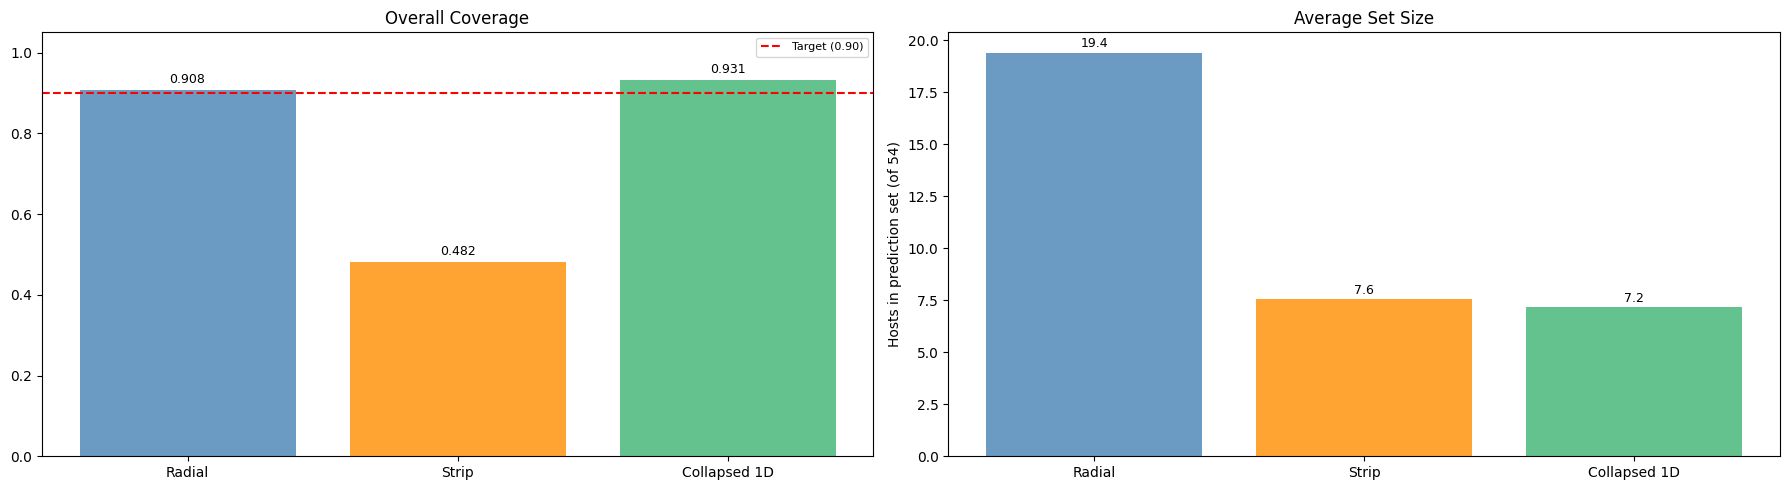

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors = ["steelblue", "darkorange", "mediumseagreen"]

# Overall coverage
ax = axes[0]
vals = [m["coverage"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.legend(fontsize=8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Average set size
ax = axes[1]
vals = [m["avg_set_size"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.set_title("Average Set Size")
ax.set_ylabel(f"Hosts in prediction set (of {len(all_hosts)})")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f"{val:.1f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

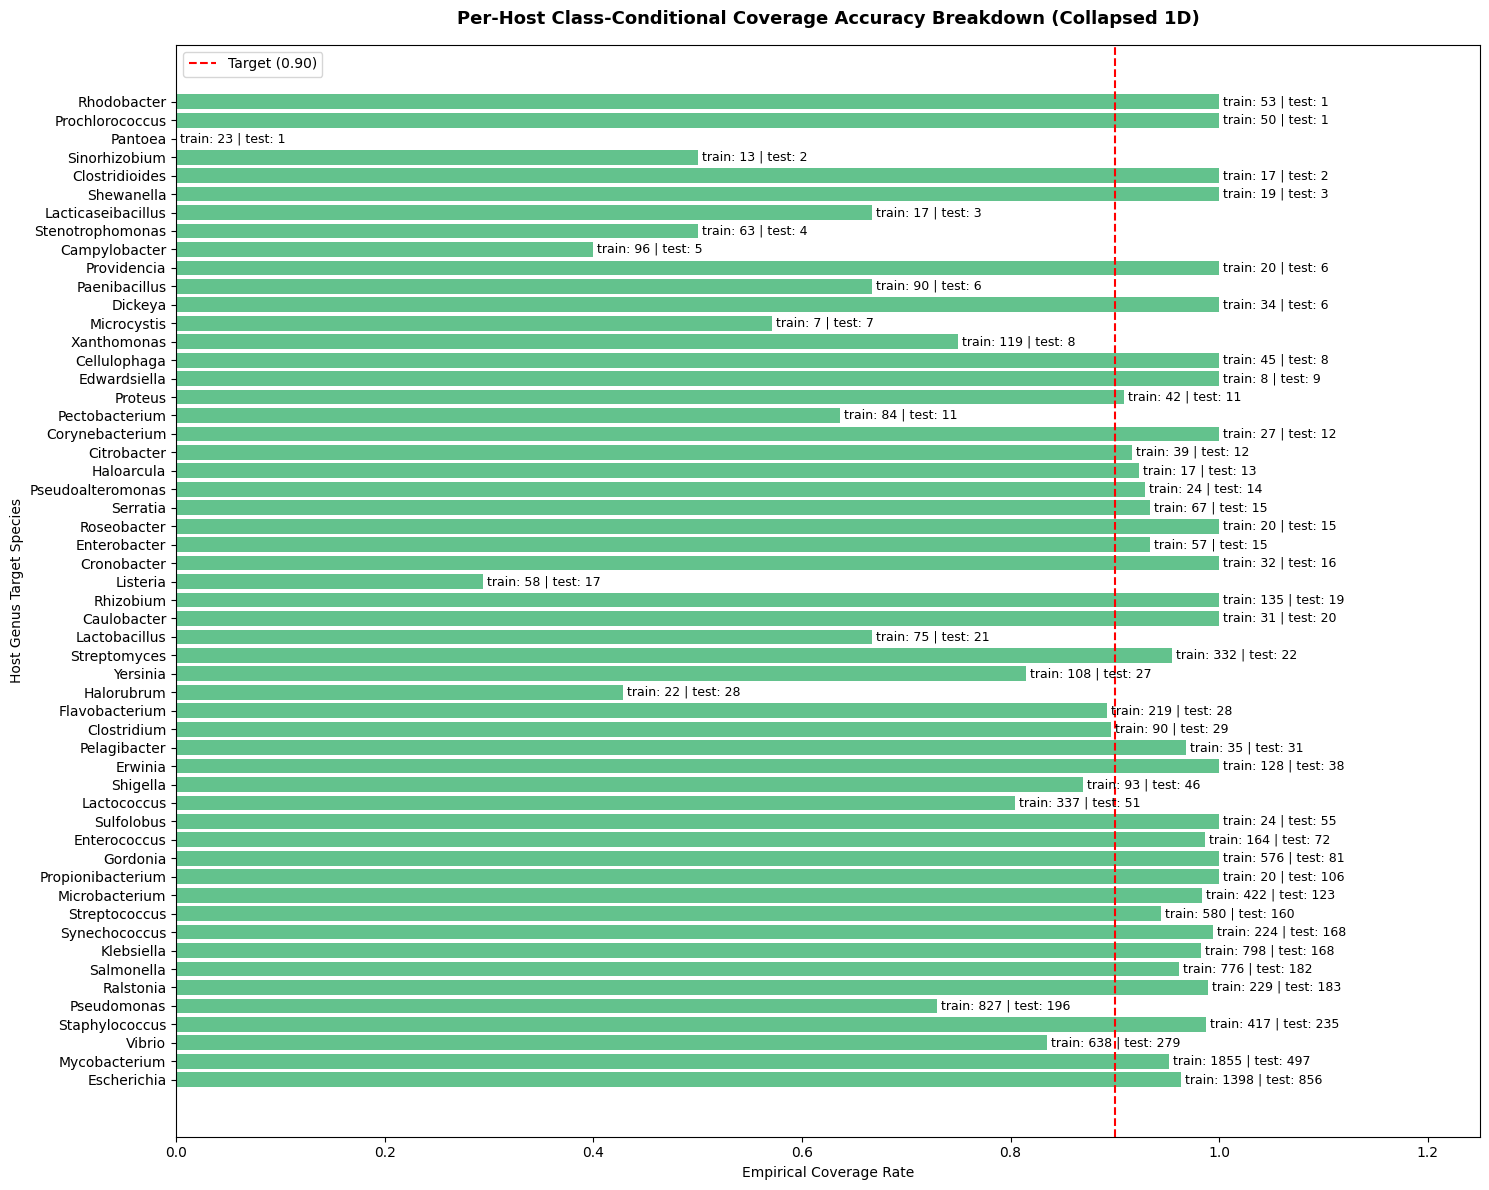

In [67]:
# Empirical Horizontal Bar Formatting Logic
train_counts = train_df["host"].value_counts().to_dict()
test_counts = test_df["host"].value_counts().to_dict()
hosts_sorted = sorted(all_hosts, key=lambda h: test_counts.get(h, 0), reverse=True)

plt.figure(figsize=(15, 12))
coverage_vals = [collapsed_metrics["per_host_coverage"].get(h, 0.0) for h in hosts_sorted]
bars = plt.barh(hosts_sorted, coverage_vals, color="mediumseagreen", alpha=0.8)
plt.axvline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")

for bar, h in zip(bars, hosts_sorted):
    n_train = train_counts.get(h, 0)
    n_test = test_counts.get(h, 0)
    label_text = f" train: {n_train} | test: {n_test}"
    plt.text(x=bar.get_width(), y=bar.get_y() + bar.get_height()/2, s=label_text, va='center', ha='left', fontsize=9)

plt.xlim(0, 1.25)
plt.title("Per-Host Class-Conditional Coverage Accuracy Breakdown (Collapsed 1D)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Empirical Coverage Rate")
plt.ylabel("Host Genus Target Species")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [68]:
results_to_plot = strip_results 

host_set_sizes = []
for i, res in enumerate(results_to_plot):
    host_set_sizes.append({
        "True Host": test_labels[i],
        "Set Size": len(res["prediction_set"])
    })

df_set_sizes = pd.DataFrame(host_set_sizes)
df_stats = (df_set_sizes.groupby("True Host")["Set Size"].agg(["count", "mean", "median", "min", "max"]).reset_index().sort_values(by="mean", ascending=False))

print("=== PER-HOST SET SIZE STATISTICS ===")
print(df_stats.to_string(index=False))

=== PER-HOST SET SIZE STATISTICS ===
         True Host  count      mean  median  min  max
   Prochlorococcus      1 13.000000    13.0   13   13
        Sulfolobus     55 12.672727    13.0   11   14
        Shewanella      3 12.000000    12.0   11   13
      Pelagibacter     31 11.806452    12.0    9   14
       Roseobacter     15 11.400000    12.0    9   13
           Proteus     11 11.363636    11.0    9   13
           Dickeya      6 11.333333    11.0   11   13
       Escherichia    856 11.177570    12.0    5   14
      Cellulophaga      8 11.125000    12.5    7   13
        Haloarcula     13 11.076923    11.0    8   13
         Ralstonia    183 10.972678    12.0    6   13
        Halorubrum     28 10.964286    11.0    8   14
        Salmonella    182 10.703297    11.0    4   14
     Campylobacter      5 10.600000    11.0    7   13
            Vibrio    279 10.534050    11.0    5   14
        Klebsiella    168 10.494048    11.0    5   14
          Yersinia     27 10.444444    11.0  

In [69]:
all_data = []
methods_dict = {
    "Collapsed 1D": collapsed_results,
    "Radial": radial_results,
    "Strip": strip_results
}

for method_name, results_list in methods_dict.items():
    for i, res in enumerate(results_list):
        all_data.append({
            "True Host": test_labels[i],
            "Set Size": len(res["prediction_set"]),
            "Envelope Type": method_name
        })

df_all_sets = pd.DataFrame(all_data)
overall_stats = df_all_sets.groupby("Envelope Type")["Set Size"].agg(["mean", "median", "max"])
print("=== OVERALL SET SIZE COMPARISON ===")
print(overall_stats)

=== OVERALL SET SIZE COMPARISON ===
                    mean  median  max
Envelope Type                        
Collapsed 1D    7.153651     7.0   18
Radial         19.406187    20.0   38
Strip           7.576572     8.0   14


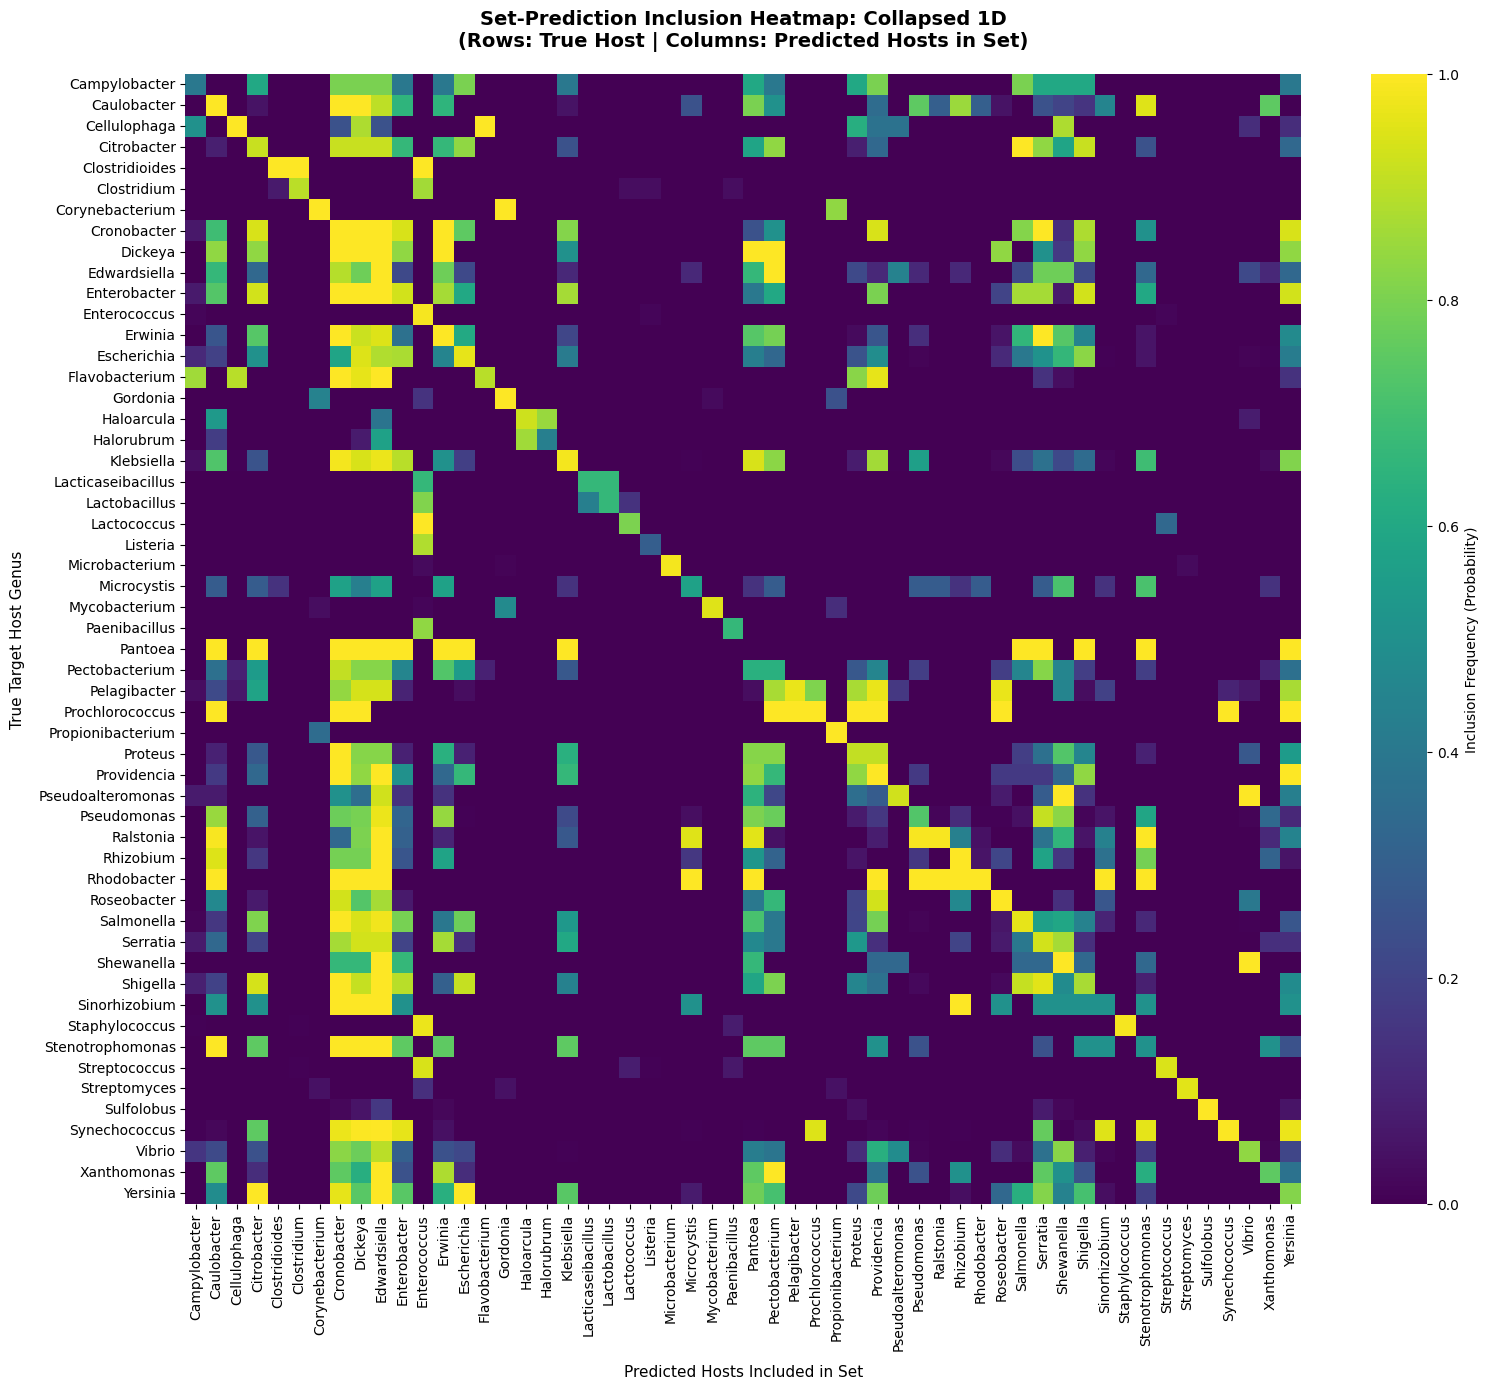

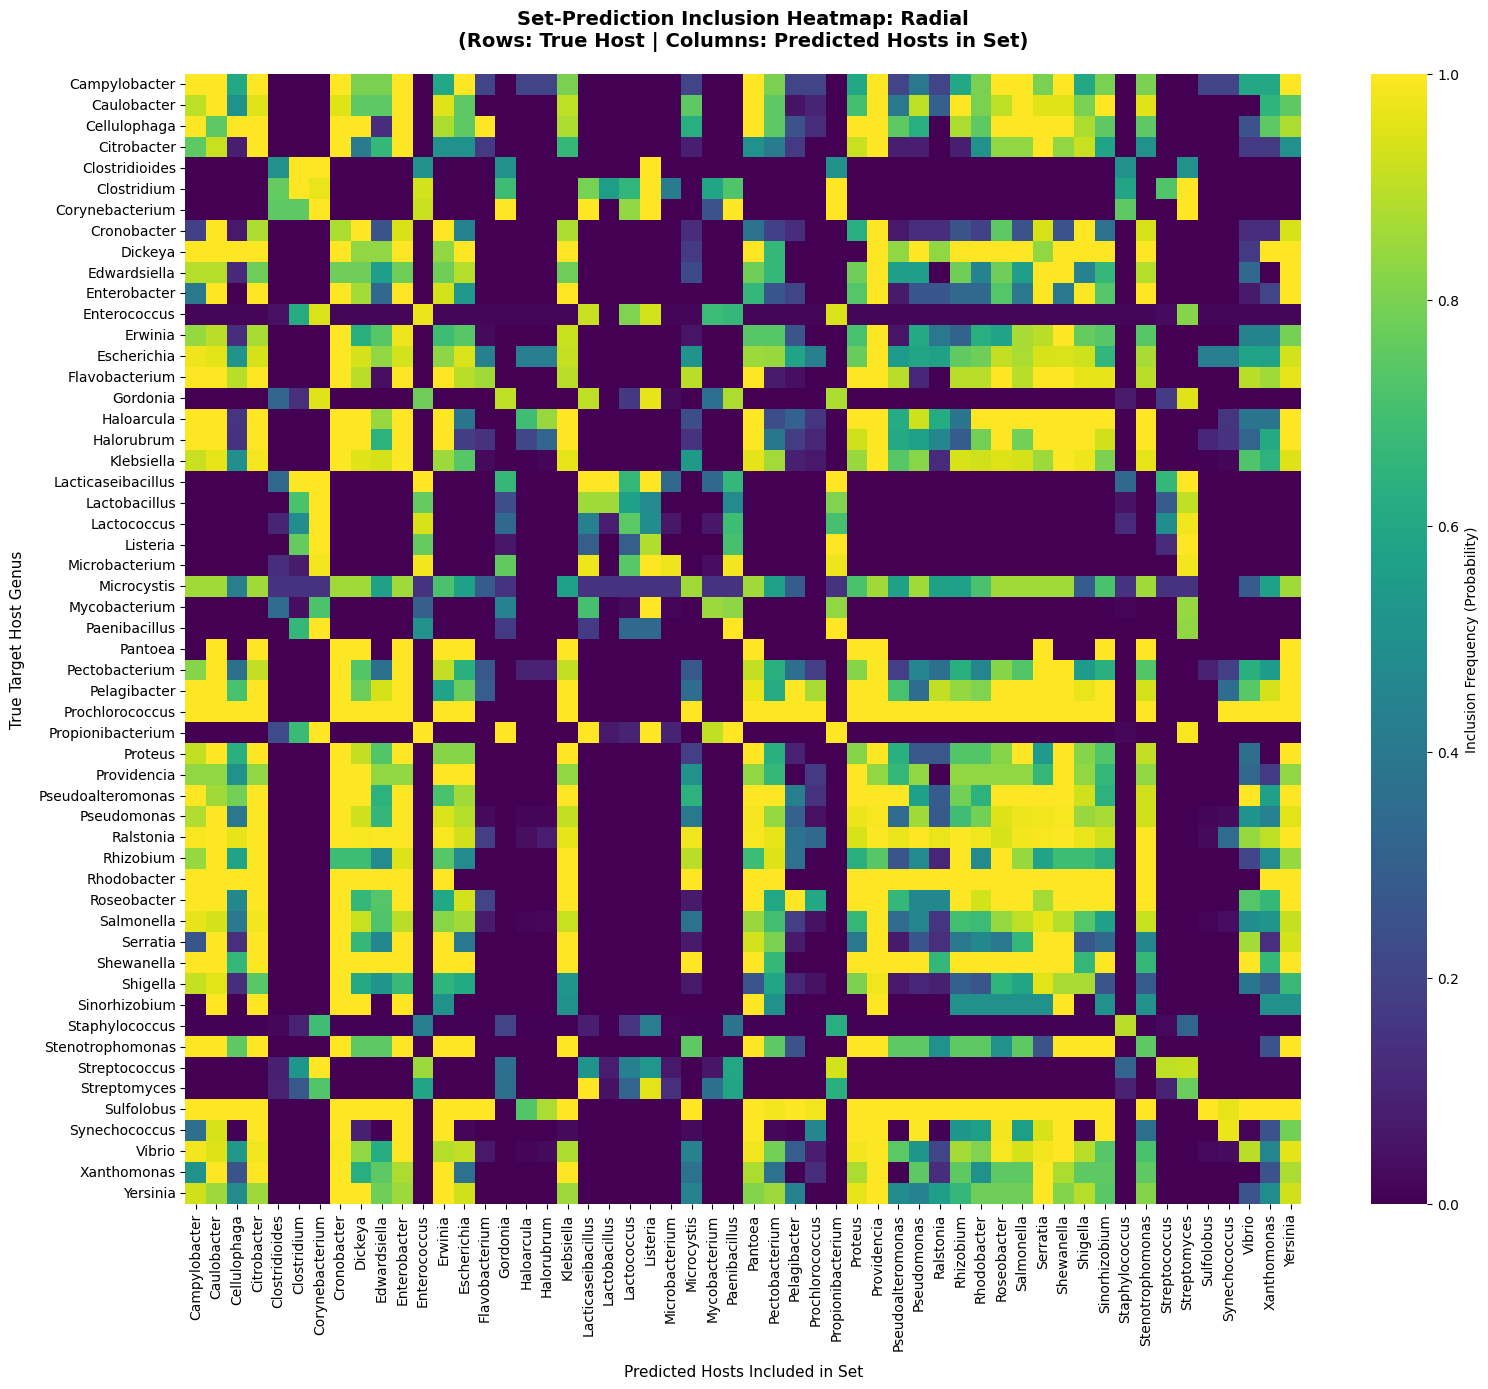

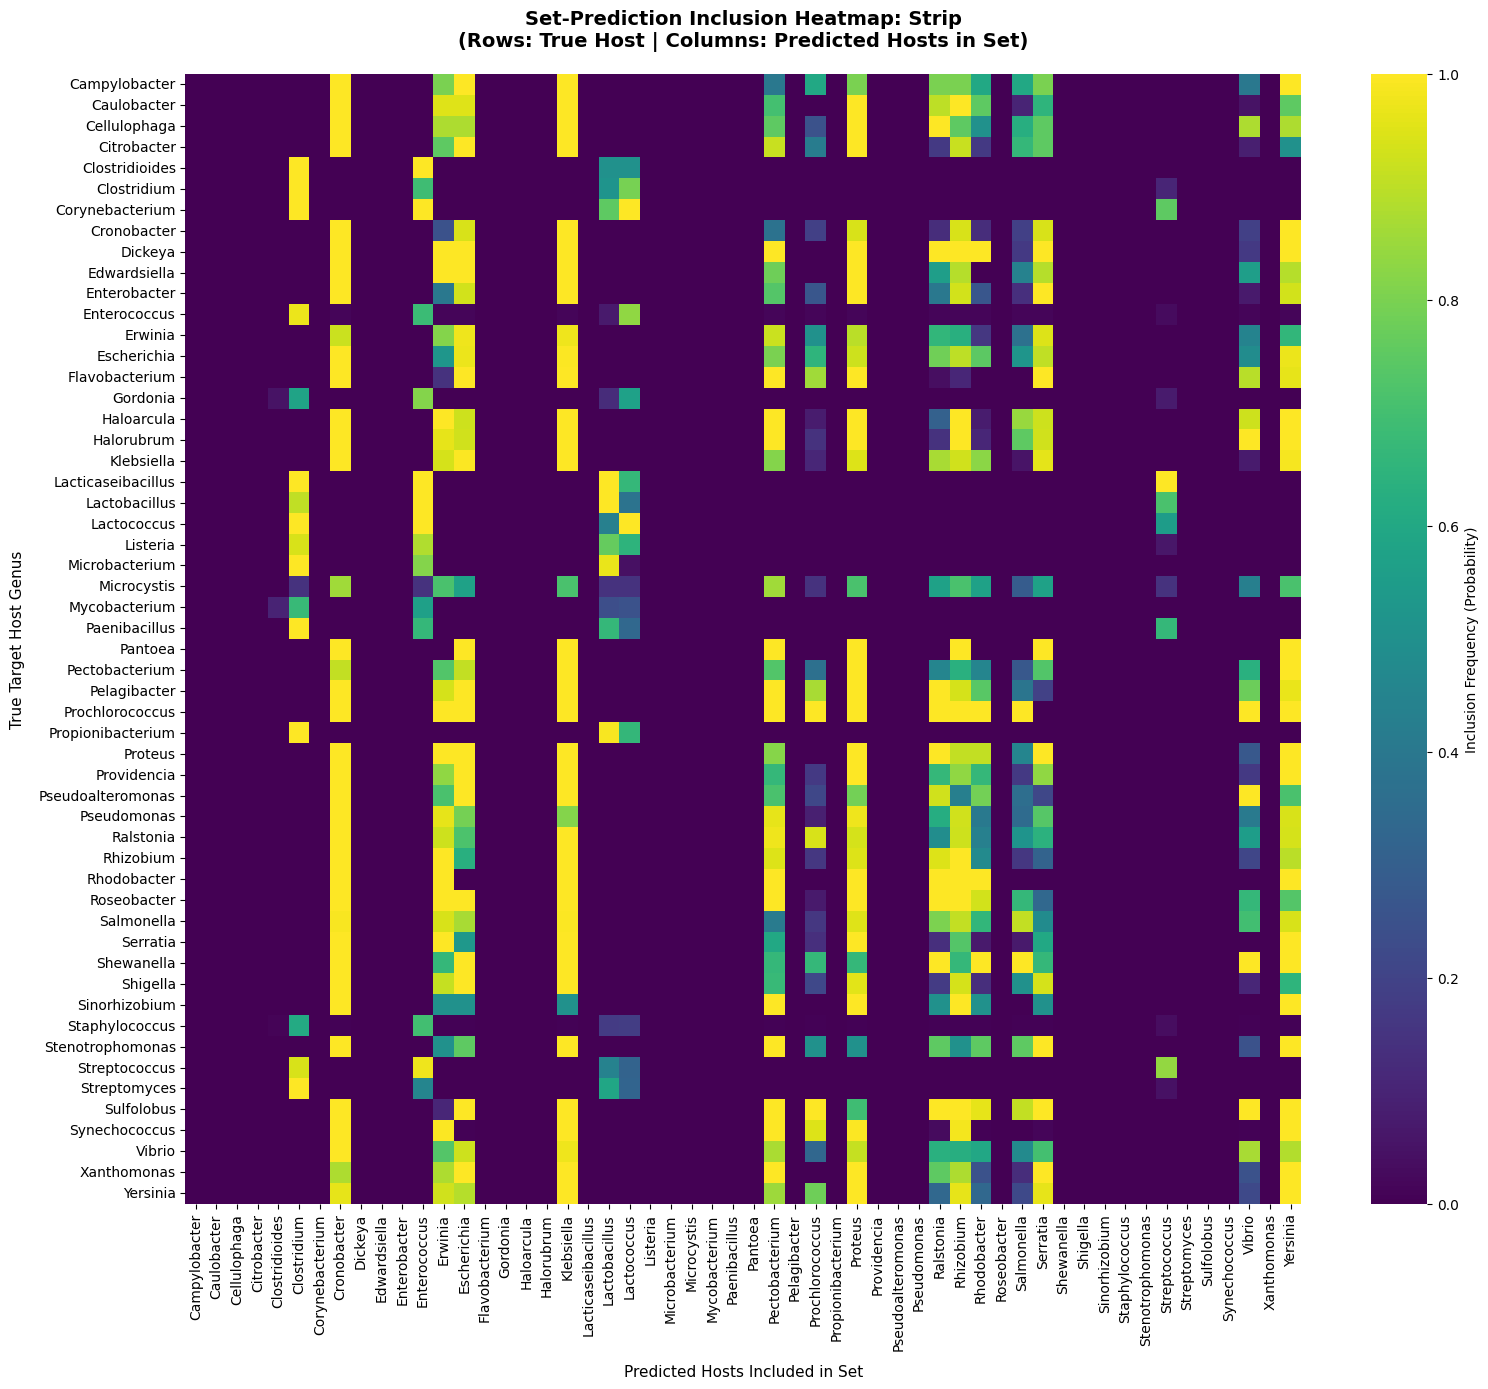

In [ ]:
import seaborn as sns
unique_hosts = sorted(list(set(test_labels)))
host_to_idx = {host: idx for idx, host in enumerate(unique_hosts)}

# Generate Heatmap Logic from visual summary reference
df_heatmap_data = []
for method_name, results_list in methods_dict.items():
    matrix_counts = np.zeros((len(unique_hosts), len(all_hosts)))
    for idx, true_lbl in enumerate(test_labels):
        row_idx = host_to_idx[true_lbl]
        pred_set = results_list[idx]["prediction_set"]
        for pred_host in pred_set:
            if pred_host in host_col_map:
                col_idx = all_hosts.index(pred_host)
                matrix_counts[row_idx, col_idx] += 1
                
    row_sums = df_set_sizes.groupby("True Host").size().reindex(unique_hosts).values[:, None]
    df_heatmap = pd.DataFrame(matrix_counts / np.where(row_sums == 0, 1, row_sums), index=unique_hosts, columns=all_hosts)
    
    plt.figure(figsize=(16, 14))
    sns.heatmap(df_heatmap, cmap="viridis", vmin=0.0, vmax=1.0, cbar_kws={'label': 'Inclusion Frequency (Probability)'}, xticklabels=True, yticklabels=True)
    plt.title(f"Set-Prediction Inclusion Heatmap: {method_name}\n(Rows: True Host | Columns: Predicted Hosts in Set)", fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted Hosts Included in Set", fontsize=11, labelpad=10)
    plt.ylabel("True Target Host Genus", fontsize=11, labelpad=10)
    plt.tight_layout()
    plt.show()

---
## 2D Function-Pair Visualization
`Staphylococcus` (good, gram-pos) vs `Clostridium` (bad, gram-pos - **both are gram-positive, so this pair specifically tests within-gram-type separation**, which is the harder case; gram-type filtering above won't help distinguish these two from each other, only from the gram-negative hosts). Functions: `lysin`, `tail_appendage`, per the PhD's suggestion - checked, not assumed, in the next cell.

In [71]:
TARGET_HOST_GOOD = "Staphylococcus"
TARGET_HOST_BAD  = "Clostridium"
FUNC_X, FUNC_Y   = "lysin", "tail_appendage"
for h in (TARGET_HOST_GOOD, TARGET_HOST_BAD):
    print(h, "-> gram type:", host_to_gramtype.get(h, "UNKNOWN"))

Staphylococcus -> gram type: gram-pos
Clostridium -> gram type: gram-pos


### Is `lysin` / `tail_appendage` actually a good choice?
Don't take this on trust - check data richness for every function these two hosts share, then see where lysin/tail_appendage actually rank.

In [72]:
funcs_good = {c.split("_", 1)[1] for c in score_cols if c.startswith(TARGET_HOST_GOOD + "_")}
funcs_bad  = {c.split("_", 1)[1] for c in score_cols if c.startswith(TARGET_HOST_BAD + "_")}
shared_funcs = sorted(funcs_good & funcs_bad)
rows = []
for f in shared_funcs:
    col_good, col_bad = f"{TARGET_HOST_GOOD}_{f}", f"{TARGET_HOST_BAD}_{f}"
    n_good = train_df.loc[train_df["host"] == TARGET_HOST_GOOD, col_good].notna().sum()
    n_bad  = train_df.loc[train_df["host"] == TARGET_HOST_BAD,  col_bad].notna().sum()
    rows.append({"function": f, f"n_train_{TARGET_HOST_GOOD}": n_good,
                 f"n_train_{TARGET_HOST_BAD}": n_bad, "min_n": min(n_good, n_bad)})
richness_df = pd.DataFrame(rows).sort_values("min_n", ascending=False).reset_index(drop=True)
print(richness_df.to_string(index=False))
print(f"\nRank of lysin: {richness_df.index[richness_df['function']=='lysin'].tolist()}  "
      f"(0 = richest)")
print(f"Rank of tail_appendage: "
      f"{richness_df.index[richness_df['function']=='tail_appendage'].tolist()}  (0 = richest)")

                 function  n_train_Staphylococcus  n_train_Clostridium  min_n
           DNA-associated                     417                   90     90
                      pvp                     417                   88     88
                   capsid                     414                   88     88
                     tail                     417                   87     87
   cell_wall_depolymerase                     412                   87     87
                    lysis                     414                   87     87
                terminase                     414                   86     86
                    holin                     410                   86     86
       packaging_assembly                     415                   86     86
                    lysin                     413                   86     86
                endolysin                     410                   86     86
           tail_appendage                     358               

### Raw score scatter — each host scored in its own column space
For each envelope (Staph's columns, Clostridium's columns), plot BOTH hosts' true phages. If the columns actually separate hosts, the wrong-host points should cluster low on both axes.

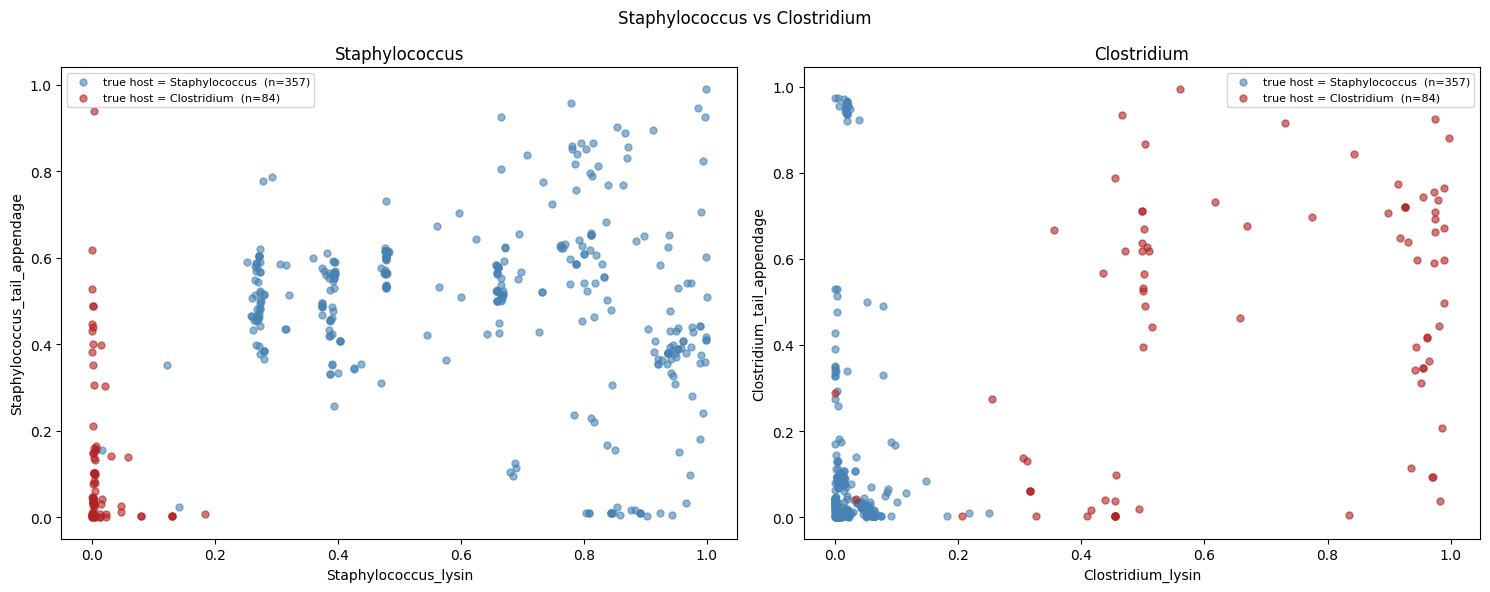

In [73]:
def get_2d_scores(df, envelope_host, func_x, func_y):
    cx, cy = f"{envelope_host}_{func_x}", f"{envelope_host}_{func_y}"
    return df[[cx, cy]].rename(columns={cx: func_x, cy: func_y}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, envelope_host in zip(axes, [TARGET_HOST_GOOD, TARGET_HOST_BAD]):
    for true_host, color in [(TARGET_HOST_GOOD, "steelblue"), (TARGET_HOST_BAD, "firebrick")]:
        sub = train_df[train_df["host"] == true_host]
        pts = get_2d_scores(sub, envelope_host, FUNC_X, FUNC_Y)
        ax.scatter(pts[FUNC_X], pts[FUNC_Y], alpha=0.6, s=25, color=color,
                   label=f"true host = {true_host}  (n={len(pts)})")
    ax.set_xlabel(f"{envelope_host}_{FUNC_X}")
    ax.set_ylabel(f"{envelope_host}_{FUNC_Y}")
    ax.set_title(f"{envelope_host}")
    ax.legend(fontsize=8)
plt.suptitle(f"{TARGET_HOST_GOOD} vs {TARGET_HOST_BAD}")
plt.tight_layout()
plt.show()

### Building dedicated 2D envelopes and checking how they actually behave
These are separate from the K_h-dimensional envelopes built above - built here using only these 2 columns, purely so the shape is visualizable. Note `M=5` for strip here, not `M=20` - your project summary already flagged M=20 as too fine for host-level sample sizes; no reason to repeat that in a 2-D toy case with even less data per bin.

In [74]:
def build_2d_envelope(train_df, envelope_host, func_x, func_y, alpha, method, seed=42, M=5):
    cx, cy = f"{envelope_host}_{func_x}", f"{envelope_host}_{func_y}"
    sub = train_df[train_df["host"] == envelope_host]
    raw = sub[[cx, cy]].dropna().values
    nc = raw_to_nc(raw)
    rng = np.random.default_rng(seed)
    n = len(nc)
    idx = rng.permutation(n)
    half = n // 2
    S1, S2 = nc[idx[:half]], nc[idx[half:]]
    labels_S2 = np.array([envelope_host] * len(S2))
    if method == "collapsed":
        return collapsed_build_envelope(S1, S2, labels_S2, [envelope_host], alpha)
    elif method == "radial":
        return radial_build_envelope(S1, S2, labels_S2, [envelope_host], alpha)
    else:
        return strip_build_envelope(S1, S2, labels_S2, [envelope_host], alpha, M=M)

methods_2d = ["collapsed", "radial", "strip"]
envelope_hosts = [TARGET_HOST_GOOD, TARGET_HOST_BAD]
envs_2d = {eh: {m: build_2d_envelope(train_df, eh, FUNC_X, FUNC_Y, alpha, m) for m in methods_2d}
           for eh in envelope_hosts}

print(f"{'envelope':<15}{'method':<12}{'own-host coverage':<20}{'other-host false-pos rate':<28}")
for eh in envelope_hosts:
    other = TARGET_HOST_BAD if eh == TARGET_HOST_GOOD else TARGET_HOST_GOOD
    own_raw = get_2d_scores(test_df[test_df["host"] == eh], eh, FUNC_X, FUNC_Y).values
    other_raw = get_2d_scores(test_df[test_df["host"] == other], eh, FUNC_X, FUNC_Y).values
    for m in methods_2d:
        env = envs_2d[eh][m]
        own_in = is_in_region(raw_to_nc(own_raw), env).mean() if len(own_raw) else float("nan")
        other_in = is_in_region(raw_to_nc(other_raw), env).mean() if len(other_raw) else float("nan")
        print(f"{eh:<15}{m:<12}{own_in:<20.3f}{other_in:<28.3f}")
print("\nown-host coverage should land near", 1 - alpha, "- if it's far off, n is too small for a "
      "reliable 2D calibration split. other-host false-pos rate is the number that actually matters "
      "for whether Staph vs Clostridium are separable on these 2 functions alone.")

envelope       method      own-host coverage   other-host false-pos rate   
Staphylococcus collapsed   0.970               0.273                       
Staphylococcus radial      0.948               0.000                       
Staphylococcus strip       0.983               0.000                       
Clostridium    collapsed   0.682               0.004                       
Clostridium    radial      0.682               0.004                       
Clostridium    strip       0.682               0.000                       

own-host coverage should land near 0.9 - if it's far off, n is too small for a reliable 2D calibration split. other-host false-pos rate is the number that actually matters for whether Staph vs Clostridium are separable on these 2 functions alone.


### Plotting the envelope boundaries
Explicit boundary line drawn only for **collapsed** (a straight threshold on the mean of the 2 NC dims - easy to draw exactly). For radial/strip the inside/outside coloring shows the effective boundary shape empirically; I did not derive exact boundary curves for those two, so don't read a precise line into what you see beyond the point coloring.

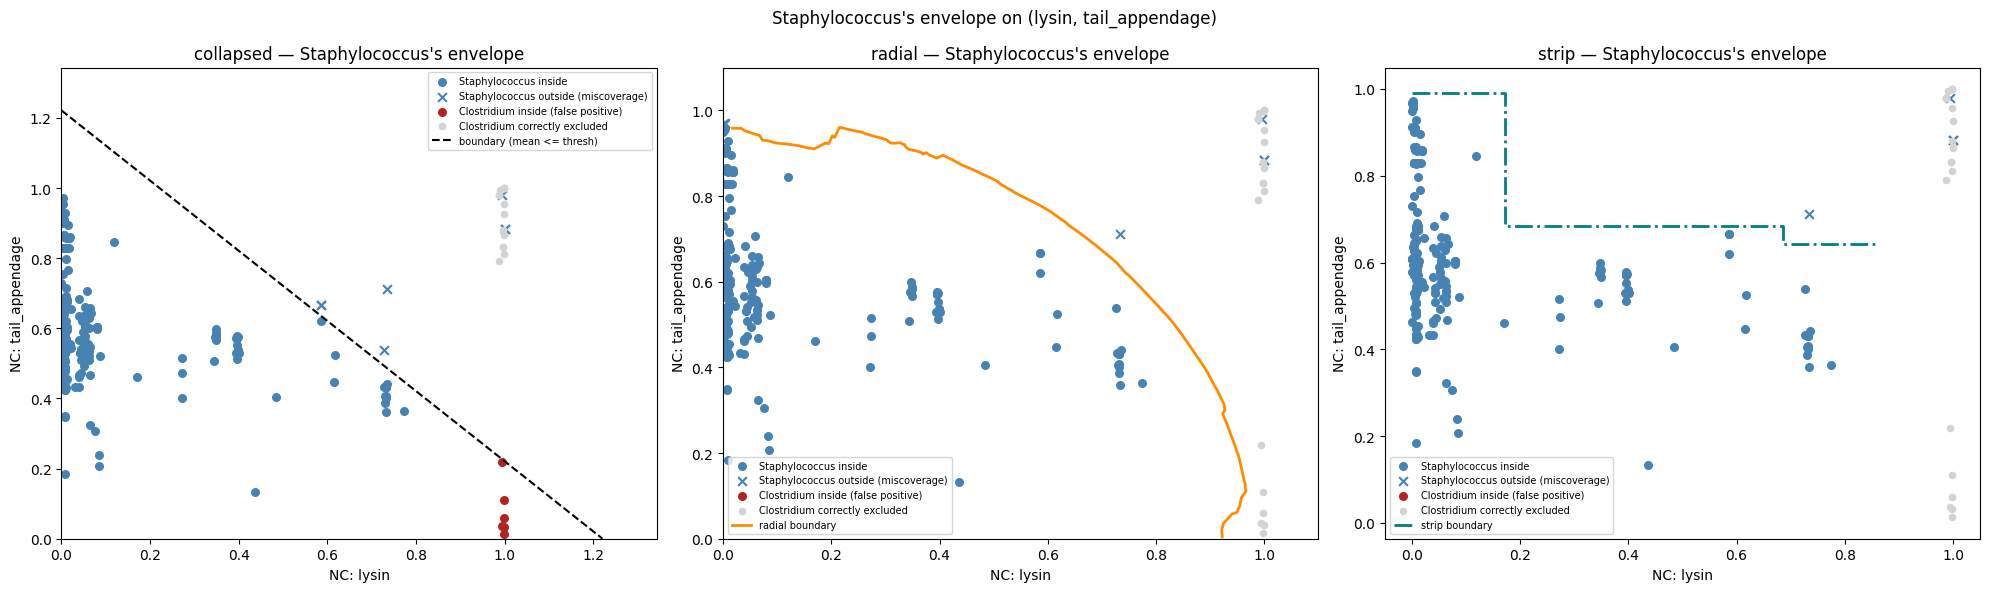

In [80]:
eh, other = TARGET_HOST_GOOD, TARGET_HOST_BAD
own_raw = get_2d_scores(test_df[test_df["host"] == eh], eh, FUNC_X, FUNC_Y)
other_raw = get_2d_scores(test_df[test_df["host"] == other], eh, FUNC_X, FUNC_Y)
own_nc, other_nc = raw_to_nc(own_raw.values), raw_to_nc(other_raw.values)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, m in zip(axes, methods_2d):
    env = envs_2d[eh][m]
    own_in = is_in_region(own_nc, env) if len(own_nc) else np.array([])
    other_in = is_in_region(other_nc, env) if len(other_nc) else np.array([])
    if len(own_nc):
        ax.scatter(own_nc[own_in, 0], own_nc[own_in, 1], color="steelblue", s=30, label=f"{eh} inside")
        ax.scatter(own_nc[~own_in, 0], own_nc[~own_in, 1], color="steelblue", s=40, marker="x", label=f"{eh} outside (miscoverage)")
    if len(other_nc):
        ax.scatter(other_nc[other_in, 0], other_nc[other_in, 1], color="firebrick", s=30, label=f"{other} inside (false positive)")
        ax.scatter(other_nc[~other_in, 0], other_nc[~other_in, 1], color="lightgray", s=20, label=f"{other} correctly excluded")
    if m == "collapsed":
        thresh = env["q_tilde"] * env["t_hat"]
        lim = max([a.max() for a in (own_nc, other_nc) if len(a)] + [2 * thresh]) * 1.1
        ax.plot([0, 2 * thresh], [2 * thresh, 0], "k--", lw=1.5, label="boundary (mean <= thresh)")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    elif m == "radial":
        U, q_t, t_h = env["U"], env["q_tilde"], env["t_hat"]
        boundary = U * (q_t * t_h)[:, None]
        ang = np.arctan2(boundary[:, 1], boundary[:, 0])
        order = np.argsort(ang)
        ax.plot(boundary[order, 0], boundary[order, 1], c="darkorange", lw=2, label="radial boundary")
        lim = max(boundary.max(), own_nc[np.isfinite(own_nc)].max() if len(own_nc) else 0) * 1.1
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    elif m == "strip":
        bin_edges, limits, t_h = env["bin_edges"], env["limits"], env["t_hat"]
        M_s = bin_edges.shape[1] - 1
        xs, ys = [], []
        for k in range(M_s):
            lo, hi = bin_edges[0, k], bin_edges[0, k + 1]
            y_lim = limits[0, 1, k] * t_h
            xs += [lo, hi]; ys += [y_lim, y_lim]
        ax.plot(xs, ys, c="teal", lw=2, ls="-.", label="strip boundary")
    ax.set_xlabel(f"NC: {FUNC_X}"); ax.set_ylabel(f"NC: {FUNC_Y}")
    ax.set_title(f"{m} — {eh}'s envelope")
    ax.legend(fontsize=7)
plt.suptitle(f"{eh}'s envelope on ({FUNC_X}, {FUNC_Y})")
plt.tight_layout()
plt.show()

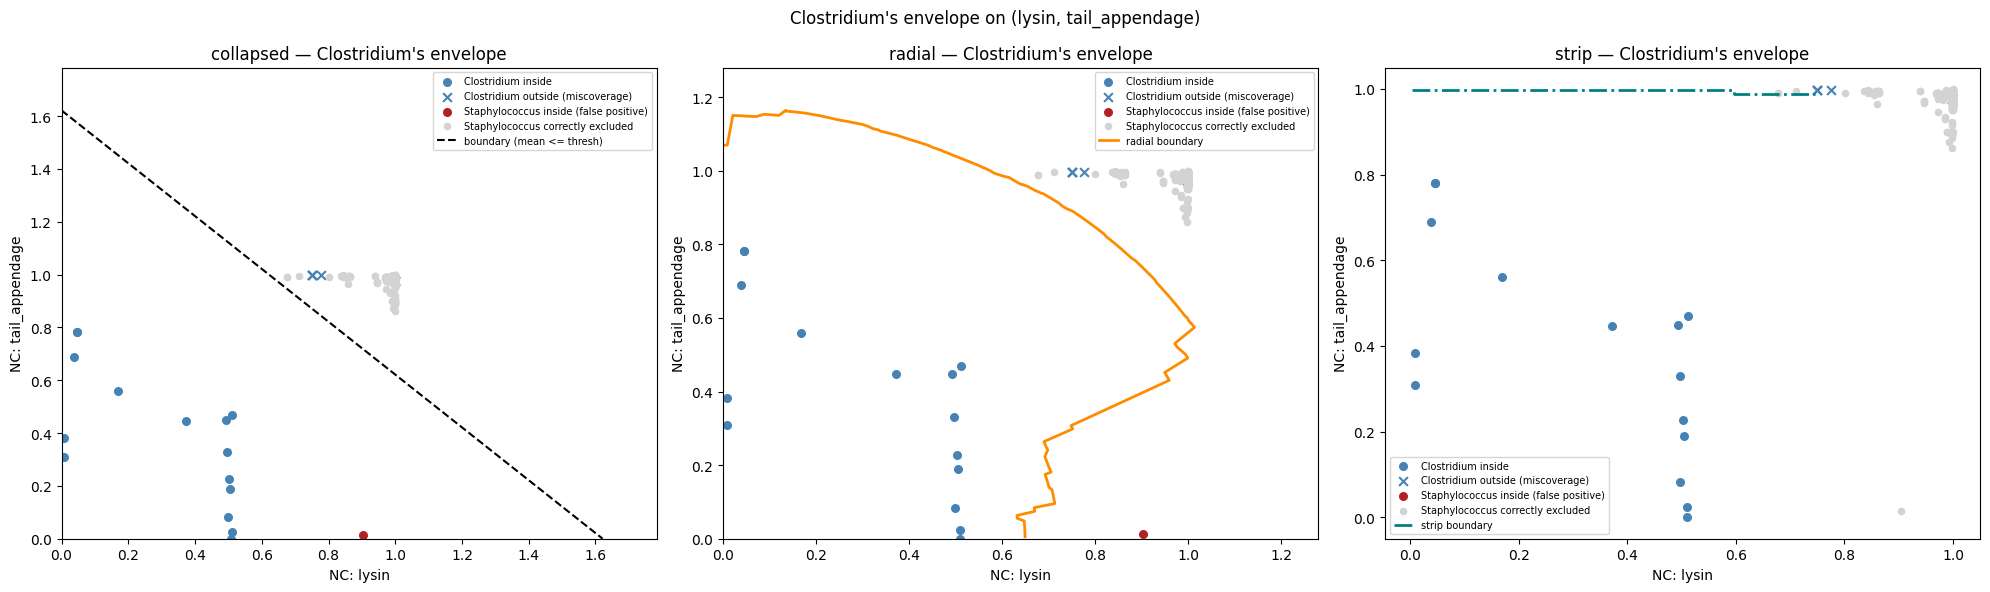

In [79]:
other, eh = TARGET_HOST_GOOD, TARGET_HOST_BAD
own_raw = get_2d_scores(test_df[test_df["host"] == eh], eh, FUNC_X, FUNC_Y)
other_raw = get_2d_scores(test_df[test_df["host"] == other], eh, FUNC_X, FUNC_Y)
own_nc, other_nc = raw_to_nc(own_raw.values), raw_to_nc(other_raw.values)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, m in zip(axes, methods_2d):
    env = envs_2d[eh][m]
    own_in = is_in_region(own_nc, env) if len(own_nc) else np.array([])
    other_in = is_in_region(other_nc, env) if len(other_nc) else np.array([])
    if len(own_nc):
        ax.scatter(own_nc[own_in, 0], own_nc[own_in, 1], color="steelblue", s=30, label=f"{eh} inside")
        ax.scatter(own_nc[~own_in, 0], own_nc[~own_in, 1], color="steelblue", s=40, marker="x", label=f"{eh} outside (miscoverage)")

    if len(other_nc):
        ax.scatter(other_nc[other_in, 0], other_nc[other_in, 1], color="firebrick", s=30, label=f"{other} inside (false positive)")
        ax.scatter(other_nc[~other_in, 0], other_nc[~other_in, 1], color="lightgray", s=20, label=f"{other} correctly excluded")

    if m == "collapsed":
        thresh = env["q_tilde"] * env["t_hat"]
        lim = max([a.max() for a in (own_nc, other_nc) if len(a)] + [2 * thresh]) * 1.1
        ax.plot([0, 2 * thresh], [2 * thresh, 0], "k--", lw=1.5, label="boundary (mean <= thresh)")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    elif m == "radial":
        U, q_t, t_h = env["U"], env["q_tilde"], env["t_hat"]
        boundary = U * (q_t * t_h)[:, None]
        ang = np.arctan2(boundary[:, 1], boundary[:, 0])
        order = np.argsort(ang)
        ax.plot(boundary[order, 0], boundary[order, 1], c="darkorange", lw=2, label="radial boundary")
        lim = max(boundary.max(), own_nc[np.isfinite(own_nc)].max() if len(own_nc) else 0) * 1.1
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    elif m == "strip":
        bin_edges, limits, t_h = env["bin_edges"], env["limits"], env["t_hat"]
        M_s = bin_edges.shape[1] - 1
        xs, ys = [], []
        for k in range(M_s):
            lo, hi = bin_edges[0, k], bin_edges[0, k + 1]
            y_lim = limits[0, 1, k] * t_h
            xs += [lo, hi]; ys += [y_lim, y_lim]
        ax.plot(xs, ys, c="teal", lw=2, ls="-.", label="strip boundary")

    ax.set_xlabel(f"NC: {FUNC_X}"); ax.set_ylabel(f"NC: {FUNC_Y}")
    ax.set_title(f"{m} — {eh}'s envelope")
    ax.legend(fontsize=7)
plt.suptitle(f"{eh}'s envelope on ({FUNC_X}, {FUNC_Y})")
plt.tight_layout()
plt.show()

### Broader per-function comparison
Not just the 2 chosen functions - the richest shared functions found above, side by side, so you can see whether lysin/tail_appendage were actually the best pick or just a reasonable guess.

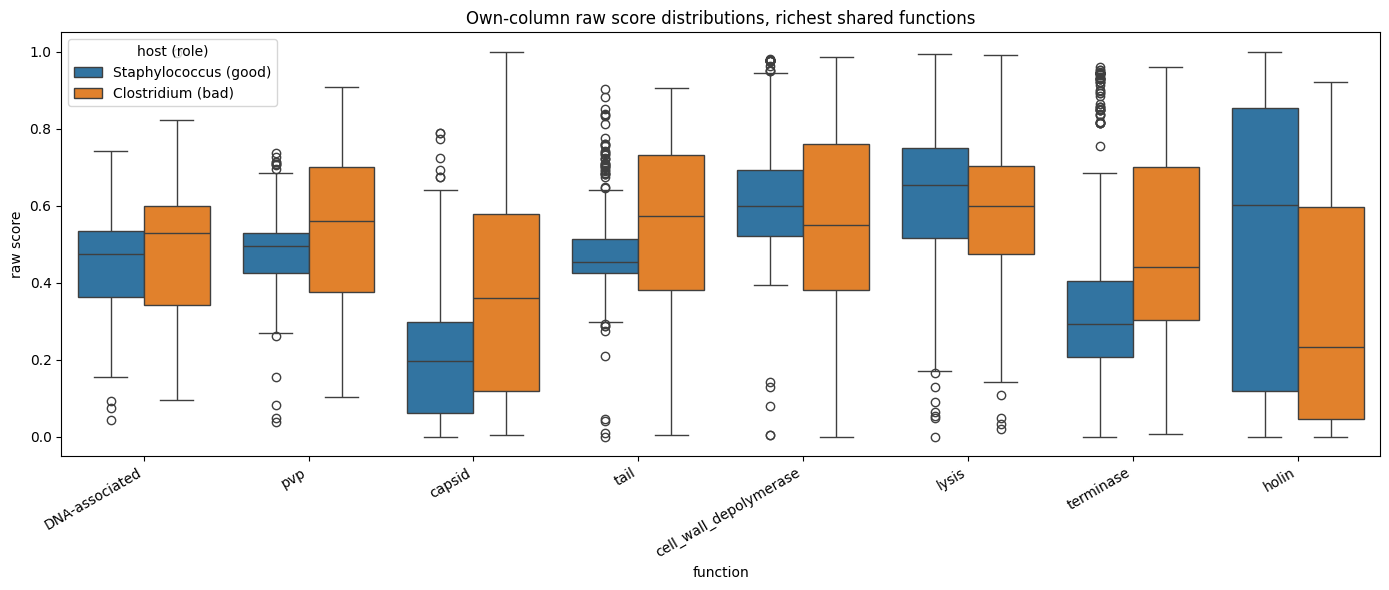

In [77]:
import seaborn as sns
top_funcs = richness_df.head(8)["function"].tolist()
plot_rows = []
for f in top_funcs:
    for host, role in [(TARGET_HOST_GOOD, "good"), (TARGET_HOST_BAD, "bad")]:
        col = f"{host}_{f}"
        for v in train_df.loc[train_df["host"] == host, col].dropna():
            plot_rows.append({"function": f, "host (role)": f"{host} ({role})", "raw score": v})
plot_df = pd.DataFrame(plot_rows)
plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_df, x="function", y="raw score", hue="host (role)")
plt.title("Own-column raw score distributions, richest shared functions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

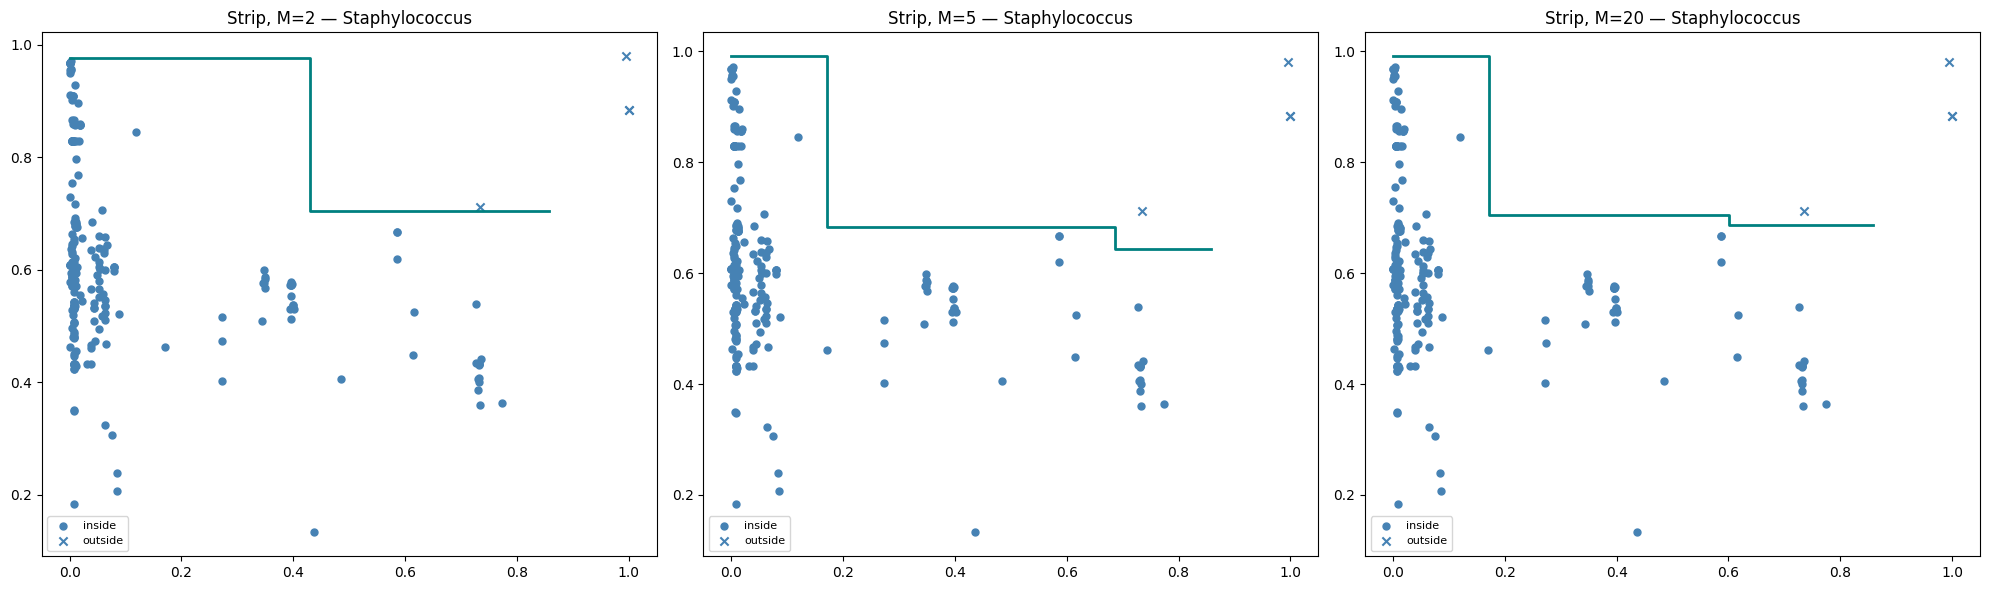

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, M_test in zip(axes, [2, 5, 20]):
    env_M = build_2d_envelope(train_df, TARGET_HOST_GOOD, FUNC_X, FUNC_Y, alpha, "strip", M=M_test)
    own_in = is_in_region(own_nc, env_M)
    ax.scatter(own_nc[own_in, 0], own_nc[own_in, 1], color="steelblue", s=25, label="inside")
    ax.scatter(own_nc[~own_in, 0], own_nc[~own_in, 1], color="steelblue", marker="x", s=35, label="outside")
    bin_edges, limits, t_h = env_M["bin_edges"], env_M["limits"], env_M["t_hat"]
    xs, ys = [], []
    for k in range(bin_edges.shape[1] - 1):
        lo, hi = bin_edges[0, k], bin_edges[0, k + 1]
        xs += [lo, hi]; ys += [limits[0, 1, k] * t_h] * 2
    ax.plot(xs, ys, c="teal", lw=2)
    ax.set_title(f"Strip, M={M_test} — {TARGET_HOST_GOOD}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Kicking out hosts with less than 50 test points

In [82]:
MIN_TRAIN_COUNT = 50   # tune this — try 50, 100, 150 and compare

train_counts = train_df["host"].value_counts()
rich_hosts = sorted(h for h in all_hosts if train_counts.get(h, 0) >= MIN_TRAIN_COUNT)
print(f"Keeping {len(rich_hosts)} of {len(all_hosts)} hosts (>= {MIN_TRAIN_COUNT} training phages)")

per_host_envs_s_rich = build_per_host_envelopes(
    train_nc, train_labels, rich_hosts, score_cols, host_col_map, alpha,
    method="strip", seed=42
)

test_mask_rich = np.isin(test_labels, rich_hosts)
strip_results_rich = predict_host(test_raw[test_mask_rich], per_host_envs_s_rich, rich_hosts)
strip_metrics_rich = evaluate_multiclass(strip_results_rich, test_labels[test_mask_rich], rich_hosts, alpha)

print(f"\nStrip, rich hosts only : coverage={strip_metrics_rich['coverage']:.3f}  "
      f"avg_set_size={strip_metrics_rich['avg_set_size']:.2f}")
print(f"Strip, all 54 hosts    : coverage={strip_metrics['coverage']:.3f}  "
      f"avg_set_size={strip_metrics['avg_set_size']:.2f}")

Keeping 32 of 54 hosts (>= 50 training phages)
  Built 32 host envelopes

Strip, rich hosts only : coverage=0.523  avg_set_size=13.36
Strip, all 54 hosts    : coverage=0.482  avg_set_size=7.58


In [83]:
def build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                              method="collapsed", seed=42, strip_M=2):
    rng = np.random.default_rng(seed)
    envelopes = {}

    for h in all_hosts:
        h_idx = host_col_map[h]
        if len(h_idx) == 0:
            continue

        mask_h = train_labels == h
        n_h = mask_h.sum()
        if n_h < 6:
            # Too few training phages to split S1/S2 meaningfully
            print(f"  SKIP {h}: only {n_h} training phages")
            continue

        train_nc_h = train_nc[mask_h][:, h_idx]   # (n_h, K_h)

        # 50/50 shuffle split into S1 and S2
        idx = rng.permutation(n_h)
        half = n_h // 2
        S1 = train_nc_h[idx[:half]]
        S2 = train_nc_h[idx[half:]]
        labels_S2 = np.array([h] * len(S2))

        if method == "collapsed":
            env = collapsed_build_envelope(S1, S2, labels_S2, [h], alpha)
        elif method == "radial":
            env = radial_build_envelope(S1, S2, labels_S2, [h], alpha)
        else:
            env = strip_build_envelope(S1, S2, labels_S2, [h], alpha, M=strip_M)   # was: alpha) with default M=2

        envelopes[h] = {"envelope": env, "col_indices": h_idx}

    print(f"  Built {len(envelopes)} host envelopes")
    return envelopes

In [84]:
for M_test in [2, 5, 10, 20, 40]:
    envs = build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map,
                                     alpha, method="strip", seed=42, strip_M=M_test)
    results = predict_host(test_raw, envs, all_hosts)
    metrics = evaluate_multiclass(results, test_labels, all_hosts, alpha)
    print(f"M={M_test:3d}  coverage={metrics['coverage']:.3f}  avg_set_size={metrics['avg_set_size']:.2f}")

  Built 54 host envelopes
M=  2  coverage=0.482  avg_set_size=15.84
  Built 54 host envelopes
M=  5  coverage=0.510  avg_set_size=15.47
  Built 54 host envelopes
M= 10  coverage=0.514  avg_set_size=15.73
  Built 54 host envelopes
M= 20  coverage=0.426  avg_set_size=15.28
  Built 54 host envelopes
M= 40  coverage=0.514  avg_set_size=14.66


In [85]:
for M_test in [2, 5, 10, 20]:
    env = build_2d_envelope(train_df, "Clostridium", FUNC_X, FUNC_Y, alpha, "strip", M=M_test)
    own_raw = get_2d_scores(test_df[test_df["host"] == "Clostridium"], "Clostridium", FUNC_X, FUNC_Y).values
    own_nc = raw_to_nc(own_raw)
    cov = is_in_region(own_nc, env).mean() if len(own_nc) else float("nan")
    print(f"Clostridium, M={M_test:3d}: own-host coverage = {cov:.3f}")

Clostridium, M=  2: own-host coverage = 0.682
Clostridium, M=  5: own-host coverage = 0.682
Clostridium, M= 10: own-host coverage = 0.682
Clostridium, M= 20: own-host coverage = 0.682


In [86]:
train_counts_sorted = train_df["host"].value_counts().sort_values(ascending=False)
n = len(train_counts_sorted)
quartile_hosts = [
    train_counts_sorted.index[0],           # richest
    train_counts_sorted.index[n // 4],       # upper-middle
    train_counts_sorted.index[n // 2],       # median
    train_counts_sorted.index[3 * n // 4],   # lower-middle
    train_counts_sorted.index[-1],           # sparsest
]
print(list(zip(quartile_hosts, train_counts_sorted[quartile_hosts])))

[('Mycobacterium', 1855), ('Synechococcus', 224), ('Stenotrophomonas', 63), ('Pseudoalteromonas', 24), ('Microcystis', 7)]
